# Data Mining Project — Checkpoint 2: Research Question Formation

**Dataset:** WELFake: A Dataset for Fake News Detection in Text Data  
**Source** (Zenodo):
https://zenodo.org/records/4561253


## Dataset recap
According to the Zenodo record, WELFake contains **72,134 accessible news articles**, with **4 columns**: serial number, title, text, and label. The labels are **0 = fake** and **1 = real**. The record also notes that the dataset combines multiple prior fake-news sources to reduce overfitting to a single data source.

#Project Scope

### Dataset
- **Unit of analysis:** one news article per row
- **Main fields:** title, text, label
- **Prediction target:** label (fake vs. real)

### Course techniques planned
- Text preprocessing
- Bag-of-words / **TF-IDF**
- Classical supervised classification:
  - Multinomial Naive Bayes
  - Logistic Regression
  - Linear SVM
- Model evaluation using F1, precision, recall, and confusion matrices

### External technique planned
- **Transformer-based text representations** (Sentence-BERT embeddings or DistilBERT-style contextual embeddings)

In [ ]:
# Core imports
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_selection import chi2

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)


## Data loading and preprocessing

### Why these preprocessing choices were made

- **Drop rows with missing text or label:** these rows cannot support supervised text classification.
- **Fill missing title with an empty string:** titles are useful, but a missing title should not force us to discard an otherwise valid article.
- **Create a combined text field (title + text):** fake-news signals may appear in both headlines and article bodies, and combining them provides a stronger baseline representation.
- **Remove exact duplicates based on the combined text and label:** duplicate rows can inflate performance and bias the analysis.

In [ ]:
data_path = "WELFake_Dataset.csv"

df_raw = pd.read_csv(data_path)
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (72134, 4)


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terr...,No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of N...,"Now, most of the demonstrators gathered last night were exercising their constitutional and protected right to peac...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid",A dozen politically active pastors came here for a private dinner Friday night to hear a conversion story unique in ...,0
4,4,SATAN 2: Russia unvelis an image of its terrifying new ‘SUPERNUKE’ – Western world takes notice,"The RS-28 Sarmat missile, dubbed Satan 2, will replace the SS-18 Flies at 4.3 miles (7km) per sec and with a range o...",1


In [ ]:
# Standardize column names for safety
df = df_raw.copy()
df.columns = [c.strip().lower() for c in df.columns]

expected_cols = {"title", "text", "label"}
missing = expected_cols - set(df.columns)
if missing:
    raise ValueError(f"Expected columns {expected_cols}, but missing: {missing}")

# Keep only the fields needed for this project stage
keep_cols = [c for c in ["id", "title", "text", "label"] if c in df.columns]
df = df[keep_cols].copy()

# Basic missingness check
missing_summary = df.isna().sum().to_frame("missing_count")
missing_summary["missing_pct"] = 100 * missing_summary["missing_count"] / len(df)
missing_summary


,missing_count,missing_pct
title,558,0.773560
text,39,0.054066
label,0,0.000000


In [ ]:
# Preprocessing
df["title"] = df["title"].fillna("")
df = df.dropna(subset=["text", "label"]).copy()
df["text"] = df["text"].astype(str)
df["title"] = df["title"].astype(str)
df["label"] = df["label"].astype(int)

# Combine title and body because both may carry useful signals
df["combined_text"] = (df["title"].str.strip() + " " + df["text"].str.strip()).str.strip()

# Remove empty combined text rows
df = df[df["combined_text"].str.len() > 0].copy()

# Remove exact duplicates to reduce leakage / redundancy
before_dedup = len(df)
df = df.drop_duplicates(subset=["combined_text", "label"]).copy()
after_dedup = len(df)

print("Rows after cleaning:", len(df))
print("Duplicates removed:", before_dedup - after_dedup)
print("Class distribution:")
print(df["label"].value_counts().sort_index())

Rows after cleaning: 63637
Duplicates removed: 8458
Class distribution:
label
0    34790
1    28847
Name: count, dtype: int64


## Additional EDA for research-question design

The checkpoint-1 notebook already examined class balance, article length, vocabulary size, and duplicates.  
For Checkpoint 2, I added EDA that is more directly tied to method selection and feasibility:

1. **Title length vs. body length**
   - helps decide whether title-only and text-only models are interesting to compare

2. **Duplicate rate after cleaning**
   - important for leakage risk and realistic evaluation

3. **Top n-grams by class**
   - helps identify whether lexical signals exist strongly enough for TF-IDF-based models

4. **Quick baseline feasibility run**
   - confirms that a course method is practical and gives measurable signal before final modeling

In [ ]:
# Length-based features for EDA
df["title_word_count"] = df["title"].apply(lambda s: len(str(s).split()))
df["text_word_count"] = df["text"].apply(lambda s: len(str(s).split()))
df["combined_word_count"] = df["combined_text"].apply(lambda s: len(str(s).split()))
df["title_char_count"] = df["title"].str.len()
df["text_char_count"] = df["text"].str.len()

summary_by_label = (
    df.groupby("label")[["title_word_count", "text_word_count", "combined_word_count"]]
      .agg(["mean", "median", "std"])
      .round(2)
)
summary_by_label

title_word_count              text_word_count                 \
                  mean median   std            mean median     std   
label                                                                
0                11.05   11.0  2.85          578.27  427.0  564.40   
1                12.90   13.0  4.81          499.66  374.0  659.17   

      combined_word_count                 
                     mean median     std  
label                                     
0                  589.32  438.0  565.23  
1                  512.56  388.0  659.15

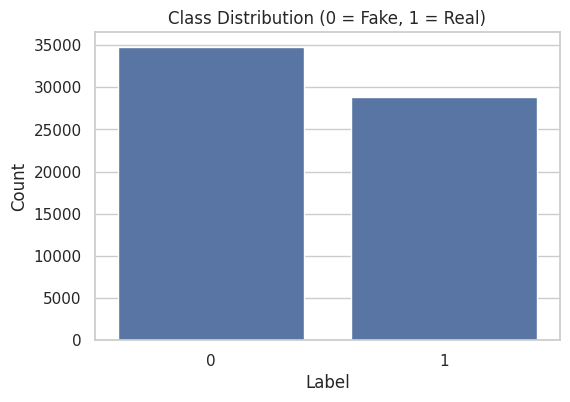

In [ ]:
# Class distribution plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="label")
ax.set_title("Class Distribution (0 = Fake, 1 = Real)")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
plt.show()

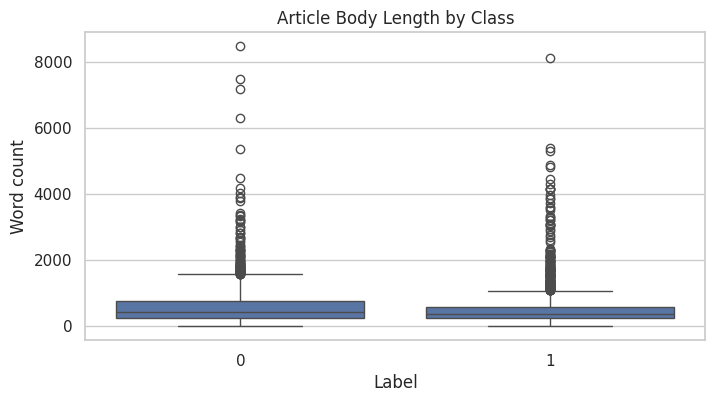

In [ ]:
# Article body length by class
plt.figure(figsize=(8, 4))
sns.boxplot(data=df.sample(min(len(df), 5000), random_state=RANDOM_STATE),
            x="label", y="text_word_count")
plt.title("Article Body Length by Class")
plt.xlabel("Label")
plt.ylabel("Word count")
plt.show()

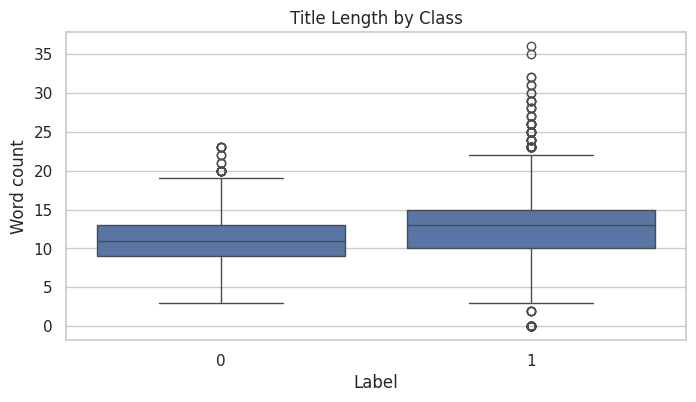

In [ ]:
# Title length by class
plt.figure(figsize=(8, 4))
sns.boxplot(data=df.sample(min(len(df), 5000), random_state=RANDOM_STATE),
            x="label", y="title_word_count")
plt.title("Title Length by Class")
plt.xlabel("Label")
plt.ylabel("Word count")
plt.show()

In [ ]:
# Exact duplicate checks at different granularities
duplicate_stats = pd.Series({
    "duplicate_titles": int(df.duplicated(subset=["title"]).sum()),
    "duplicate_texts": int(df.duplicated(subset=["text"]).sum()),
    "duplicate_combined_text_label_pairs": int(df.duplicated(subset=["combined_text", "label"]).sum()),
})
duplicate_stats.to_frame("count")


,count
duplicate_titles,1328
duplicate_texts,921
duplicate_combined_text_label_pairs,0


In [ ]:
# Top unigram features by class using simple count vectors
# This EDA checks whether strong lexical signals exist for course methods like TF-IDF.
sample_df = df.sample(min(len(df), 12000), random_state=RANDOM_STATE).copy()

fake_texts = sample_df.loc[sample_df["label"] == 0, "combined_text"]
real_texts = sample_df.loc[sample_df["label"] == 1, "combined_text"]

vectorizer = CountVectorizer(stop_words="english", max_features=40, ngram_range=(1, 1))
fake_mat = vectorizer.fit_transform(fake_texts)
fake_counts = np.asarray(fake_mat.sum(axis=0)).ravel()
fake_terms = pd.DataFrame({"term": vectorizer.get_feature_names_out(), "count": fake_counts}).sort_values("count", ascending=False)

vectorizer = CountVectorizer(stop_words="english", max_features=40, ngram_range=(1, 1))
real_mat = vectorizer.fit_transform(real_texts)
real_counts = np.asarray(real_mat.sum(axis=0)).ravel()
real_terms = pd.DataFrame({"term": vectorizer.get_feature_names_out(), "count": real_counts}).sort_values("count", ascending=False)

display(fake_terms.head(15))
display(real_terms.head(15))

,term,count
25,said,35005
33,trump,22301
12,mr,12723
14,new,9953
22,president,9839
19,people,7886
28,state,7849
29,states,6175
2,clinton,6155
8,government,5805


,term,count
31,trump,18110
26,said,7220
22,people,7057
4,clinton,6961
23,president,5623
14,just,5276
12,hillary,5238
16,like,4380
21,obama,4152
19,new,4062


In [ ]:
# Compare top bigrams by class
def top_ngrams(texts, ngram_range=(2, 2), max_features=20):
    vec = CountVectorizer(stop_words="english", ngram_range=ngram_range, max_features=max_features)
    mat = vec.fit_transform(texts)
    counts = np.asarray(mat.sum(axis=0)).ravel()
    return pd.DataFrame({"ngram": vec.get_feature_names_out(), "count": counts}).sort_values("count", ascending=False)

fake_bigrams = top_ngrams(fake_texts, ngram_range=(2, 2), max_features=20)
real_bigrams = top_ngrams(real_texts, ngram_range=(2, 2), max_features=20)

display(fake_bigrams.head(10))
display(real_bigrams.head(10))

,ngram,count
16,united states,4219
6,new york,3886
4,mr trump,3600
1,donald trump,3340
18,white house,2790
19,york times,1811
7,north korea,1443
9,president donald,1343
2,hillary clinton,1334
17,washington reuters,1284


,ngram,count
4,donald trump,3764
8,hillary clinton,2639
17,united states,1603
5,featured image,1460
18,white house,1401
16,twitter com,1135
11,pic twitter,1064
10,new york,1005
12,president obama,800
7,getty images,764


I performed additional EDA to better understand whether the WELFake dataset supports meaningful and feasible research questions for text mining and classification.

The length-based analysis shows some differences between the two classes. Real articles (label = 1) tend to have longer titles on average, while fake articles (label = 0) tend to have slightly longer article bodies and combined text. However, the boxplots show substantial overlap between the classes, especially for body length, along with many extreme outliers. This suggests that length-related features may provide some signal, but they are unlikely to be strong enough on their own for classification.

The duplicate analysis shows that the dataset contains 1,328 duplicate titles and 921 duplicate article texts, but no exact duplicate combined-text-and-label pairs. This means the dataset does contain some repeated content, so preprocessing decisions matter, but it does not appear to be dominated by exact duplicate labeled examples.

The unigram and bigram analysis suggests that there are clear lexical differences between the classes. Both fake and real articles frequently discuss similar political topics, but the most common words and phrases differ enough to indicate that methods such as TF-IDF, vector-space models, and word embeddings should be useful. Some phrases in the real-news class, such as featured image or twitter com, also suggest that stylistic or formatting patterns may contribute to classification performance.

Overall, this additional EDA supports research questions focused on comparing text representations, classification models, and an external method such as a transformer model, since the dataset appears to contain both structural and lexical signals without being trivially separable.

#Research Question Definition

## RQ1
**How well can course-based text representations and classifiers detect fake news in WELFake, and which classical pipeline performs best?**

- **Why this is interesting:** It directly answers the core classification problem using course techniques, and it establishes a strong baseline before adding external methods.
- **Course alignment:** TF-IDF, supervised classification, evaluation metrics
- **Data mining task type:** Text classification
- **Relevant algorithms:**  
  - TF-IDF + Multinomial Naive Bayes  
  - TF-IDF + Logistic Regression  
  - TF-IDF + Linear SVM
- **Evaluation criteria:**  
  - Macro F1  
  - Precision / Recall / F1 for each class  
  - Confusion matrix  
  - ROC-AUC where applicable
- **Why feasible:** The dataset is large, labels are available, and these methods are standard and efficient on sparse text features.

## RQ2
**Which interpretable lexical and stylistic signals most strongly distinguish fake news from real news, and are those signals consistent across title-only, text-only, and combined-text models?**

- **Why this is interesting:** This moves beyond “which classifier wins” and asks what the dataset is actually learning.
- **Course alignment:** Feature extraction, term weighting, classification, feature analysis
- **Data mining task type:** Interpretable text mining / comparative classification
- **Relevant algorithms:**  
  - TF-IDF vectorization  
  - Chi-square feature selection  
  - Logistic Regression coefficient analysis
- **Evaluation criteria:**  
  - Stability of top discriminative terms  
  - Macro F1 for title-only vs. text-only vs. combined-text models  
  - Interpretability of important features
- **Why feasible:** The dataset includes both title and body text, so comparing those representations is straightforward and meaningful.

## RQ3
**Do transformer-based contextual embeddings improve fake-news detection over TF-IDF baselines, especially for shorter or more ambiguous articles?**

- **Why this is interesting:** This is the external technique question. It tests whether richer semantic representations capture patterns missed by sparse lexical models.
- **External technique:** Transformer-based embeddings (e.g., Sentence-BERT or DistilBERT-style embeddings)
- **Data mining task type:** Advanced text classification
- **Relevant algorithms:**  
  - Sentence-BERT embeddings + Logistic Regression / Linear classifier  
  - Optional stronger extension: fine-tuned DistilBERT
- **Evaluation criteria:**  
  - Macro F1 and classwise F1  
  - Performance gap relative to TF-IDF baselines  
  - Subgroup performance by article length (short / medium / long)
- **Why feasible:** Pretrained transformer encoders can be used without training from scratch, making the method realistic for a course project while still extending beyond course content.


## Why these questions are non-trivial

These questions are not just “run a model and report accuracy.”

- **RQ1** compares multiple classical pipelines rather than assuming one default model.
- **RQ2** focuses on interpretation and representation differences, which helps explain *why* classification works.
- **RQ3** examines whether an external semantic representation truly adds value, rather than assuming transformers are always better.

Together, the questions move from:
1. **baseline performance**, to
2. **understanding learned signals**, to
3. **testing a stronger external representation**.

## RQ-to-method mapping table

| RQ | Main task type | Course or external? | Planned algorithms | Planned evaluation |
|---|---|---|---|---|
| **RQ1**: Which classical pipeline performs best? | Text classification | **Course** | TF-IDF + Naive Bayes, Logistic Regression, Linear SVM | Macro F1, classwise precision/recall/F1, confusion matrix, ROC-AUC |
| **RQ2**: Which lexical/stylistic signals distinguish fake vs real, and how do title/text representations differ? | Interpretable text mining / comparative classification | **Course** | TF-IDF, chi-square feature selection, logistic coefficients | Top features, model stability, Macro F1 for title-only/text-only/combined |
| **RQ3**: Do transformer embeddings improve detection, especially on shorter articles? | Advanced text classification | **External** | Sentence-BERT embeddings + linear classifier; optional fine-tuned DistilBERT | Macro F1, subgroup F1 by length, improvement over TF-IDF baseline |

# Motivation and Feasibility

## Motivation
Fake-news detection is a good text mining problem because the task combines:
- high-dimensional sparse text features,
- a clear supervised target,
- strong practical importance,
- and room for both interpretable and stronger semantic methods.

The EDA suggests enough structure to support meaningful modeling:
- lexical signals exist,
- text lengths vary,
- classes are reasonably balanced,
- and the dataset is large enough for robust experiments.

## Feasibility
This project is feasible because:
- the classical TF-IDF models are computationally lightweight;
- the dataset format is simple and directly usable;
- title-only, text-only, and combined-text comparisons require only minor preprocessing changes;
- transformer embeddings can be applied with pretrained models rather than training a large model from scratch.

## Risks and mitigations
- **Risk: memory/time with the full dataset**  
  **Mitigation:** start with a sampled feasibility subset, then scale up.
- **Risk: data leakage from duplicates**  
  **Mitigation:** remove duplicates before splitting.
- **Risk: transformer compute cost**  
  **Mitigation:** use frozen sentence embeddings before considering full fine-tuning.
- **Risk: overly optimistic performance from easy lexical cues**  
  **Mitigation:** compare title-only vs. body-only vs. combined-text and inspect misclassifications.


# Methodological Planning

## Planned preprocessing
- fill missing titles with empty strings
- drop rows missing text or label
- combine title + text for the main representation
- remove duplicates
- use a train/test split with a fixed random seed
- stratify by label to preserve class balance

## Planned baselines
- **Baseline 1:** majority-class baseline
- **Baseline 2:** TF-IDF + Multinomial Naive Bayes
- **Baseline 3:** TF-IDF + Logistic Regression
- **Baseline 4:** TF-IDF + Linear SVM

## Planned external method
- **Sentence-BERT or similar contextual embeddings**
  - Extract dense vector representations
  - Train a simple linear classifier on those embeddings
  - Compare directly against TF-IDF baselines

## Planned metrics
- Macro F1 (**main metric**)
- Accuracy
- Precision / recall / F1 for each class
- Confusion matrix
- ROC-AUC when model scores support it

## Why Macro F1 is the main metric
Even though the classes are fairly balanced, Macro F1 is a better project metric than plain accuracy because it gives equal importance to both fake and real labels and penalizes models that perform well on only one side.


## Initial feasibility run with a course method

This section performs a **small, professional feasibility check** before the final project modeling.  
The purpose is not to finish the whole project now, but to show that:
- the package workflow is working,
- the data has predictive signal,
- and the proposed methods are realistic.

### Why this choice
I use **TF-IDF + Logistic Regression** first because:
- it is fully aligned with course material,
- it is strong for many text-classification tasks,
- and its coefficients are later useful for RQ2 interpretability.

In [ ]:
# Small feasibility subset to keep this stage lightweight and fast
feasibility_df = df.sample(min(len(df), 12000), random_state=RANDOM_STATE).copy()

X_train, X_test, y_train, y_test = train_test_split(
    feasibility_df["combined_text"],
    feasibility_df["label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=feasibility_df["label"]
)

tfidf_logreg = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=30000,
        ngram_range=(1, 2),
        min_df=3
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

tfidf_logreg.fit(X_train, y_train)
y_pred = tfidf_logreg.predict(X_test)
y_prob = tfidf_logreg.predict_proba(X_test)[:, 1]

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:  {acc:.4f}")
print(f"Macro F1:  {f1:.4f}")
print(f"Macro Prec:{precision:.4f}")
print(f"Macro Rec: {recall:.4f}")
print(f"ROC-AUC:   {auc:.4f}")


Accuracy:  0.9254
Macro F1:  0.9245
Macro Prec:0.9251
Macro Rec: 0.9239
ROC-AUC:   0.9770


In [ ]:
# Confusion matrix for the feasibility model
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=["Fake (0)", "Real (1)"], columns=["Pred Fake", "Pred Real"])
cm_df

,Pred Fake,Pred Real
Fake (0),1244,82
Real (1),97,977


In [ ]:
# Inspect top weighted features for interpretability feasibility (supports RQ2)
feature_names = tfidf_logreg.named_steps["tfidf"].get_feature_names_out()
coefs = tfidf_logreg.named_steps["clf"].coef_[0]

top_real = pd.DataFrame({
    "feature": feature_names,
    "weight": coefs
}).sort_values("weight", ascending=False).head(15)

top_fake = pd.DataFrame({
    "feature": feature_names,
    "weight": coefs
}).sort_values("weight", ascending=True).head(15)

print("Top features pushing prediction toward REAL (label = 1):")
display(top_real)

print("Top features pushing prediction toward FAKE (label = 0):")
display(top_fake)

Top features pushing prediction toward REAL (label = 1):


,feature,weight
28494,video,6.163959
11927,hillary,4.687050
12467,image,4.544476
9671,featured image,4.522802
9670,featured,4.278145
5262,com,3.259097
13852,just,3.214899
10775,getty,2.954152
10776,getty images,2.914608
374,2016,2.874546


Top features pushing prediction toward FAKE (label = 0):


,feature,weight
22694,said,-12.289011
22017,reuters,-9.860697
3579,breitbart,-5.290691
16753,mr,-4.751932
28953,washington reuters,-3.936108
19995,president donald,-3.626294
26643,thursday,-3.006591
10418,friday,-2.922370
27755,tuesday,-2.880413
17391,new york,-2.873943


## Interpretation of the feasibility run

If the feasibility run achieves meaningful F1 above chance, it supports three important conclusions:

1. **RQ1 is feasible** because classical TF-IDF models can learn useful patterns.
2. **RQ2 is feasible** because interpretable weighted features can be extracted from the fitted model.
3. **RQ3 is justified** because the classical baseline now gives a meaningful comparison point for an external transformer-based method.

Even if the exact score changes after full-data cleaning and tuning, this run validates the overall project direction.

## External-method plan for RQ3

### Preferred external method
Use a pretrained **Sentence-BERT** model to convert each article into a dense semantic vector, then fit a simple classifier.

### Why this is a good external extension
- It is clearly outside the standard course TF-IDF pipeline.
- It is easier to run than full transformer fine-tuning.
- It provides a clean semantic comparison against sparse lexical features.

### Planned workflow
1. Use the same cleaned articles as in the TF-IDF baseline.
2. Encode text with a pretrained sentence-transformer model.
3. Train Logistic Regression or another simple classifier on the embeddings.
4. Compare Macro F1 overall and by article-length subgroup.

### Optional stronger extension
If compute allows, fine-tune DistilBERT on a subset and compare it to frozen embeddings.

# Method and Metric Plan

## Final method plan by question

### RQ1
- Train TF-IDF + Naive Bayes, Logistic Regression, and Linear SVM
- Tune a small number of reasonable hyperparameters
- Compare using Macro F1 as the primary metric

### RQ2
- Fit title-only, text-only, and combined-text models
- Extract top chi-square terms and logistic-regression coefficients
- Compare interpretability and predictive quality across representations

### RQ3
- Build transformer-embedding representations
- Train a simple classifier on those embeddings
- Compare overall and subgroup performance against the best TF-IDF baseline

# Tests and validation checks

The rubric asks for meaningful tests, not just “the notebook runs.”  
The assertions below check non-trivial preprocessing and modeling assumptions on small examples.

### Why these tests matter
- They verify that missing-title handling works.
- They verify that duplicate removal behaves as expected.
- They verify that TF-IDF feature extraction produces a usable matrix.

In [ ]:
# Test 1: missing title is safely filled and combined text still exists
toy = pd.DataFrame({
    "title": [np.nan, "Headline"],
    "text": ["Body text here", "Another body"],
    "label": [0, 1]
})
toy["title"] = toy["title"].fillna("")
toy["combined_text"] = (toy["title"].str.strip() + " " + toy["text"].str.strip()).str.strip()

assert toy.loc[0, "combined_text"] == "Body text here"
assert toy.loc[1, "combined_text"] == "Headline Another body"
print("Test 1 passed.")

Test 1 passed.


In [ ]:
# Test 2: exact duplicate removal reduces repeated rows
toy_dupes = pd.DataFrame({
    "combined_text": ["same article", "same article", "different article"],
    "label": [0, 0, 1]
})
deduped = toy_dupes.drop_duplicates(subset=["combined_text", "label"])
assert len(deduped) == 2
print("Test 2 passed.")

Test 2 passed.


In [ ]:
# Test 3: TF-IDF vectorizer creates a non-empty sparse matrix on toy data
toy_docs = ["fake news spreads fast", "real reporting uses sources", "fake headlines mislead readers"]
vec = TfidfVectorizer(stop_words="english")
X_toy = vec.fit_transform(toy_docs)

assert X_toy.shape[0] == 3
assert X_toy.shape[1] > 0
assert X_toy.nnz > 0
print("Test 3 passed.")

Test 3 passed.


## Collaboration Declaration

1. **Collaborators:** None

2. **Web Sources:**
   - WELFake dataset record on Zenodo: https://zenodo.org/records/4561253
   - scikit-learn documentation: https://scikit-learn.org/stable/
   - pandas documentation: https://pandas.pydata.org/docs/
   - matplotlib documentation: https://matplotlib.org/stable/
   - seaborn documentation: https://seaborn.pydata.org/
   - Hugging Face Transformers documentation: https://huggingface.co/docs/transformers/index
   - sentence-transformers documentation: https://www.sbert.net/

3. **AI Tools:**
   - ChatGPT: used for brainstorming research-questions.

4. **Citations for Papers Used:**
   - None